# RQ2 - Backdooring the base learner

In [ ]:
import os, sys, copy
from typing import Callable

sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from src.experiments.contrastive_ncm import (
    load_cicids2017,
    prepare_temporal_split,
    BaseLearnerMLP,
    eval_base_learner,
    AdaptiveDAdaptiveM,
    run_stream,
    initial_training,
    apply_paper_style,
    save_fig,
    save_latex,
    agg,
    set_progress,
    set_stream_verbose,
    DAY_NAMES_DEFAULT,
)
from src.detectors.contrastive_ncm import ContrastiveNCMDetector

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_float32_matmul_precision('high')

DATA_DIR = os.path.abspath('../../data/CICIDS2017_Engelen')
FIGURE_DIR = os.path.abspath('./figures')
TABLE_DIR = os.path.abspath('./tables')

NOVEL_CLASSES = ['DoS', 'PortScan']
POISON_TARGET = 'DoS'
CONCEPT_BATCH = 256
BATCH_SIZE = 1_000
DD_RETRAIN_EPOCHS = 300
DD_RETRAIN_LR = 1e-4
DD_EVAL_POOL_N = 2000
M_HIDDEN = (256, 128, 64)

POISON_FRAC = 0.15
N_TRIGGER_DIMS = 5
N_SEEDS = 3
SEEDS = [RANDOM_SEED + 1000 + i for i in range(N_SEEDS)]

PROGRESS = False
set_progress(PROGRESS)
set_stream_verbose(PROGRESS)

apply_paper_style()
DAY_NAMES = DAY_NAMES_DEFAULT


/home/azureuser/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load, preprocess, and define the trigger

In [ ]:
print('Loading CICIDS2017...')
data = load_cicids2017(DATA_DIR)
split = prepare_temporal_split(
    data, novel_classes=NOVEL_CLASSES, per_class_metric_names=NOVEL_CLASSES, random_seed=RANDOM_SEED
)

target_id = int(data.le_full.transform([POISON_TARGET])[0])
dos_pool = data.X[data.y_all == target_id].astype(np.float32)

x_min = split.X_tr.min(axis=0)
x_max = split.X_tr.max(axis=0)

TRIGGER_DIMS = np.sort(np.random.default_rng(0).choice(data.input_dim, N_TRIGGER_DIMS, replace=False))
TRIGGER_DELTA = 1.0

def stamp(X):
    """Apply the trigger: add TRIGGER_DELTA to TRIGGER_DIMS (clamped to the valid range)."""
    Xc = np.array(X, dtype=np.float32, copy=True)
    Xc[:, TRIGGER_DIMS] = np.clip(
        Xc[:, TRIGGER_DIMS] + TRIGGER_DELTA, x_min[TRIGGER_DIMS], x_max[TRIGGER_DIMS]
    )
    return Xc


print(f'Trigger dims: {TRIGGER_DIMS.tolist()}  (+{TRIGGER_DELTA} std, clamped)')

poison_pool = stamp(dos_pool)

dos_mask = split.per_class_masks['dos']
X_dos_clean = split.X_eval[dos_mask].cpu().numpy().astype(np.float32)
X_dos_trig = stamp(X_dos_clean)

batch_days = split.d_stream[::BATCH_SIZE]
POISON_UNTIL = int(np.argmax(batch_days >= 3))
print(f'Poison window = batches [0, {POISON_UNTIL}) (Mon-Wed); clean thereafter.')

Loading CICIDS2017...


Trigger dims: [20, 23, 38, 47, 62]  (+1.0 std, clamped)
Poison window = batches [0, 421) (Mon-Wed); clean thereafter.


## Initial training and builders

In [ ]:
print('Initial training...')
init = initial_training(
    X_tr=split.X_tr, y_tr_mc=split.y_tr_mc, y_tr_bin=split.y_tr_bin,
    n_known=split.n_known, input_dim=data.input_dim, device=DEVICE, random_seed=RANDOM_SEED,
)
print(f'drift_threshold={init.drift_threshold:.4f}  T={init.concept_threshold:.4f}')

_rng_pool = np.random.default_rng(RANDOM_SEED + 7)
X_dd_eval_pool = split.novel_pool[_rng_pool.choice(len(split.novel_pool), DD_EVAL_POOL_N, replace=False)]

def _fresh_detector():
    det = ContrastiveNCMDetector(
        input_dim=data.input_dim, hidden_dim=64, latent_dim=32, temperature=0.1, device=DEVICE
    )

    det.autoencoder.load_state_dict(copy.deepcopy(init.dd_init_ae))
    det.ncm = copy.deepcopy(init.dd_init_ncm)
    det.drift_threshold = init.drift_threshold
    det.concept_threshold = init.concept_threshold
    det.num_classes = split.n_known
    det._reset_drift_buffer()

    return det

def _fresh_m():
    ml = BaseLearnerMLP(data.input_dim, M_HIDDEN).to(DEVICE)
    ml.load_state_dict(copy.deepcopy(init.m_init_state))
    return ml

def fresh_full_system(n_exemplars=500):
    sys_ = AdaptiveDAdaptiveM(
        detector=_fresh_detector(), base_learner=_fresh_m(),
        X_exemplars=init.X_exemplars, y_exemplars=init.y_exemplars, y_exemplars_mc=init.y_exemplars_mc,
        m_init_state=init.m_init_state, X_eval=split.X_eval, y_eval_bin=split.y_eval_bin,
        novel_mask=split.novel_mask_eval, X_dd_eval_pool=X_dd_eval_pool, per_class_masks=split.per_class_masks,
        concept_batch=CONCEPT_BATCH, dd_retrain_epochs=DD_RETRAIN_EPOCHS, dd_retrain_lr=DD_RETRAIN_LR,
        X_cal=init.X_cal, y_cal_mc=init.y_cal_mc,
    )

    sys_.NOVEL_EXEMPLARS_PER_CONCEPT = n_exemplars
    return sys_


Initial training...


    [Contrastive 20/300] loss=0.1477


    [Contrastive 40/300] loss=0.0835


    [Contrastive 60/300] loss=0.0492


    [Contrastive 80/300] loss=0.0359


...

    [M 40/100] loss=0.0004


    [M 60/100] loss=0.0002


    [M 80/100] loss=0.0002


    [M 100/100] loss=0.0005


drift_threshold=1.3339  T=37.8378


In [ ]:
@torch.no_grad()
def dos_fnr(model, X_np):
    model.eval()
    pred = model(torch.from_numpy(X_np).to(DEVICE)).argmax(1).cpu().numpy()
    return float((pred == 0).mean())

def sustained(p):
    return lambda b: p

def poison_then_clean(p):
    return lambda b: p if b < POISON_UNTIL else 0.0

def run_condition(seed, schedule_fn, poison_frac, pool, n_exemplars):
    torch.manual_seed(seed)
    np.random.seed(seed)

    sys_ = fresh_full_system(n_exemplars=n_exemplars)
    res = run_stream(
        sys_, X_stream=split.X_stream, y_stream_bin=split.y_stream_bin, d_stream=split.d_stream,
        novel_pool=pool, poison_frac=poison_frac, schedule_fn=schedule_fn,
        rng_seed=seed, batch_size=BATCH_SIZE, min_inject_day=1, inject_label=0,
    )

    fri_f1 = float(np.mean([r.f1 for r in res if r.day_idx == 4]))
    M = sys_.base_learner
    mem_y = sys_.novel_y

    return {
        'fri_f1': fri_f1,
        'fnr_clean': dos_fnr(M, X_dos_clean),
        'fnr_trig': dos_fnr(M, X_dos_trig),
        'dd_retrains': int(getattr(sys_, 'n_dd_retrains', 0)),
        'mem_total': 0 if mem_y is None else int(len(mem_y)),
        'mem_poison': 0 if mem_y is None else int((np.asarray(mem_y) == 0).sum()),
    }

fnr_c = dos_fnr(init.base_learner, X_dos_clean)
fnr_t = dos_fnr(init.base_learner, X_dos_trig)
print(f'Sanity (initial clean M, no poison):  FNR clean={fnr_c:.3f}   FNR triggered={fnr_t:.3f}')

if fnr_t > fnr_c + 0.1:
    print('Trigger is too strong')
else:
    print('Trigger does not evade a clean M')


Sanity (initial clean M, no poison):  FNR clean=0.881   FNR triggered=0.769
Trigger does not evade a clean M


## Experiment 1: clean / backdoor-sustained / backdoor-then-clean


In [ ]:
CONDITIONS = {
    'clean':                dict(schedule_fn=None,                          poison_frac=0.0, pool=split.novel_pool, n_exemplars=500),
    'backdoor sustained':   dict(schedule_fn=sustained(POISON_FRAC),        poison_frac=0.0, pool=poison_pool,      n_exemplars=500),
    'backdoor then clean':  dict(schedule_fn=poison_then_clean(POISON_FRAC), poison_frac=0.0, pool=poison_pool,     n_exemplars=500),
}

exp1 = {name: [] for name in CONDITIONS}
for name, cfg in CONDITIONS.items():
    print(f"========== {name} ==========")

    for seed in SEEDS:
        r = run_condition(seed=seed, **cfg)
        exp1[name].append(r)
        
        print(f'seed {seed}: Fri F1={r["fri_f1"]:.3f}  FNR clean={r["fnr_clean"]:.3f}  '
              f'FNR triggered={r["fnr_trig"]:.3f}  DD-retr={r["dd_retrains"]}  mem poison={r["mem_poison"]}/{r["mem_total"]}')

========== clean ==========


    [M 20/100] loss=0.0021


    [M 40/100] loss=0.0010


    [M 60/100] loss=0.0010


    [M 80/100] loss=0.0004


...

    [Contrastive 160/300] loss=3.5722
    [Contrastive 180/300] loss=3.3388


    [Contrastive 200/300] loss=3.0738
    [Contrastive 220/300] loss=2.5200


    [Contrastive 240/300] loss=2.1980
    [Contrastive 260/300] loss=1.9611


    [Contrastive 280/300] loss=1.9346
    [Contrastive 300/300] loss=1.7918


seed 1044: Fri F1=0.782  FNR clean=0.040  FNR triggered=0.562  DD-retr=2  mem poison=704/1000


## Experiment 2: durability (exemplar-accumulation ablation)

In [ ]:
exp2 = {}
for n_ex in (500, 0):
    name = f'backdoor then clean (accum={n_ex})'
    exp2[name] = []
    print(f"========== {name} ==========")

    for seed in SEEDS:
        r = run_condition(seed=seed, schedule_fn=poison_then_clean(POISON_FRAC),
                          poison_frac=0.0, pool=poison_pool, n_exemplars=n_ex)
        exp2[name].append(r)
        
        print(f'seed {seed}: Fri F1={r["fri_f1"]:.3f}  FNR clean={r["fnr_clean"]:.3f}  '
              f'FNR triggered={r["fnr_trig"]:.3f}  DD-retr={r["dd_retrains"]}  mem poison={r["mem_poison"]}/{r["mem_total"]}')

========== backdoor then clean (accum=500) ==========


    [M 20/100] loss=0.0033


    [M 40/100] loss=0.0005


    [M 60/100] loss=0.0009


    [M 80/100] loss=0.0003


...

    [Contrastive 160/300] loss=1.2585
    [Contrastive 180/300] loss=1.3037


    [Contrastive 200/300] loss=1.2377
    [Contrastive 220/300] loss=1.2154


    [Contrastive 240/300] loss=0.9720
    [Contrastive 260/300] loss=0.9245


    [Contrastive 280/300] loss=0.8301
    [Contrastive 300/300] loss=0.6673


seed 1044: Fri F1=0.711  FNR clean=0.003  FNR triggered=1.000  DD-retr=1  mem poison=0/0


## Results

,Fri F1,FNR clean DoS,FNR triggered DoS,DD retrains
Condition,,,,
clean,0.787 ± 0.055,0.012 ± 0.005,0.014 ± 0.005,2.333 ± 1.247
backdoor sustained,0.387 ± 0.254,0.588 ± 0.414,0.846 ± 0.109,0.333 ± 0.471
backdoor then clean,0.850 ± 0.051,0.034 ± 0.005,0.687 ± 0.096,2.333 ± 0.471
backdoor then clean (accum=500),0.850 ± 0.051,0.034 ± 0.005,0.687 ± 0.096,2.333 ± 0.471
backdoor then clean (accum=0),0.747 ± 0.041,0.014 ± 0.015,0.679 ± 0.454,1.333 ± 0.471


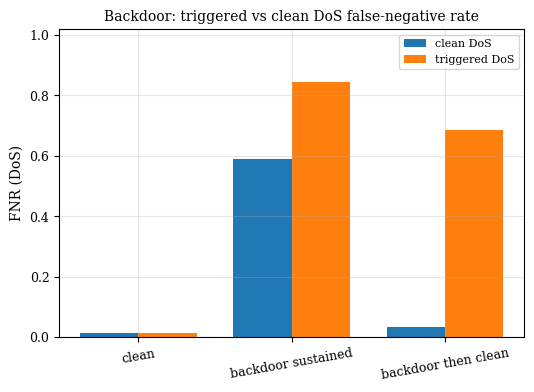

In [ ]:
rows = []
for name, runs in {**exp1, **exp2}.items():
    rows.append({
        'Condition': name,
        'Fri F1': agg([r['fri_f1'] for r in runs]),
        'FNR clean DoS': agg([r['fnr_clean'] for r in runs]),
        'FNR triggered DoS': agg([r['fnr_trig'] for r in runs]),
        'DD retrains': agg([float(r['dd_retrains']) for r in runs]),
    })

summary = pd.DataFrame(rows).set_index('Condition')

display(summary)
save_latex(summary, 'rq2_backdoor.tex', TABLE_DIR,
           caption='Backdooring the base learner through the composition channel. Benign-labelled '
                   'DoS flows carrying a fixed feature-space trigger are injected (sustained, or '
                   'poison-then-clean) and harvested into the retraining set. A backdoor is implanted when '
                   'the false-negative rate on triggered DoS is high while clean-DoS FNR and overall '
                   '$F_1$ are unchanged. Mean +/- std over three seeds; the accum=0 row disables the '
                   'never-evict memory.',
           label='tab:rq2-backdoor')


fig, ax = plt.subplots(figsize=(6, 4))
labels = ['clean', 'backdoor sustained', 'backdoor then clean']
x = np.arange(len(labels)); w = 0.38
clean = [np.mean([r['fnr_clean'] for r in exp1[l]]) for l in labels]
trig = [np.mean([r['fnr_trig'] for r in exp1[l]]) for l in labels]
ax.bar(x - w/2, clean, w, label='clean DoS')
ax.bar(x + w/2, trig, w, label='triggered DoS')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=10)
ax.set_ylabel('FNR (DoS)'); ax.set_ylim(0, 1.02)
ax.set_title('Backdoor: triggered vs clean DoS false-negative rate'); ax.legend()
save_fig(fig, 'rq2_backdoor', FIGURE_DIR)
plt.show()